# ANÁLISIS DEL CONSUMO DE GAS EN ESPAÑA

Este proyecto consiste en la modelización y predicción de la serie temporal del consumo total de gas natural en España. Para llevar a cabo este análisis se aplica la metodología iterativa de Box-Jenkins, orientada a ajustar modelos SARIMA capaces de capturar la dinámica de la serie y generar pronósticos precisos. Todo el desarrollo técnico y computacional se implementa en Python.

La metodología de Box-Jenkins se articula en tres etapas fundamentales previas a la predicción:

1. Identificación: Consiste en analizar las propiedades estadísticas de la serie temporal original para determinar si presenta componentes de tendencia y estacionalidad, así como evaluar su no estacionariedad en varianza y en media. Mediante inspección gráfica y contrastes formales (como el test de Bartlett), se evalúa la necesidad de transformaciones de estabilización de varianza (logaritmos). Posteriormente, se analiza el grado de diferenciación regular y estacional requerido y, a partir del análisis de las funciones de autocorrelación simple (ACF) y parcial (PACF), se proponen especificaciones tentativas.

2. Estimación y Validación: A continuación, se estiman los parámetros de los modelos candidatos comprobando su significación estadística. En este punto se incorporan criterios de validación cruzada y evaluación fuera de muestra (*train/test split* y métricas como el MAPE) para medir la capacidad predictiva real de cada especificación.

3. Diagnosis de Residuos: Finalmente, se valida que el modelo seleccionado sea econométricamente adecuado. Para ello, se comprueba que sus residuos cumplan con las propiedades de ruido blanco débil: media nula, estacionariedad estricta, ausencia de correlación serial (mediante el test de Ljung-Box y correlogramas) y homocedasticidad condicional e incondicional (mediante el test ARCH-LM).

Una vez superadas satisfactoriamente estas fases, el modelo final se calibra para proyectar la demanda con sus correspondientes intervalos de confianza.

### Librerías a utilizar

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import bartlett

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.seasonal import seasonal_decompose
import statsmodels.tsa.holtwinters as ets
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import het_arch

from sklearn.metrics import mean_absolute_percentage_error
import pmdarima as pm

### Carga de datos

Cargamos el archivo CSV aplicando los delimitadores correspondientes y depuramos la estructura inicial para quedarnos con la serie agregada y construir un índice temporal mensual ('MS').

In [2]:
gas = pd.read_csv('data/consumo_gas.csv', sep = ';', thousands = '.')
gas.head()

,Año,Mes,TOTAL,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21
0,2004,enero,27829,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2004,febrero,27420,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2004,marzo,29592,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2004,abril,25025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2004,mayo,24062,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Abrimos el CSV con Pandas y nos quedamos solo con el consumo total, para posteriormente añadir a mano las fechas.

In [3]:
gas = gas['TOTAL']
gas

0      27829
1      27420
2      29592
3      25025
4      24062
       ...  
266    27697
267    24046
268    24261
269    23778
270    27494
Name: TOTAL, Length: 271, dtype: int64

Generamos un rango de fechas con frecuencia mensual de inicio de mes (MS) que abarca todo el histórico disponible, desde enero de 2004 hasta julio de 2026, para establecerlo como índice temporal de la serie.

In [4]:
fechas = pd.date_range('2004-01-01','2026-07-01', 
               freq='MS').strftime("%Y-%m").tolist()
fechas = pd.Series(fechas)
fechas

0      2004-01
1      2004-02
2      2004-03
3      2004-04
4      2004-05
        ...   
266    2026-03
267    2026-04
268    2026-05
269    2026-06
270    2026-07
Length: 271, dtype: str

Juntamos en el DataFrame las columnas de meses y consumo.

In [5]:
Gas = pd.concat([fechas, gas], axis = 1)

Gas.columns = ['Month', 'gas_consumption']
Gas.head()

,Month,gas_consumption
0,2004-01,27829
1,2004-02,27420
2,2004-03,29592
3,2004-04,25025
4,2004-05,24062


Finalmente, indicamos  la columna de los meses como el indice para que sea una serie temporal y poder realizar el analisis.

In [6]:
# Convertir en Serie Temporal
Gas.set_index(['Month'], inplace = True)
Gas.index = pd.to_datetime(Gas.index)
Gas

,gas_consumption
Month,
2004-01-01,27829
2004-02-01,27420
2004-03-01,29592
2004-04-01,25025
2004-05-01,24062
...,...
2026-03-01,27697
2026-04-01,24046
2026-05-01,24261


### Descripción de la serie

El objetivo de este proyecto consiste en modelizar y predecir la demanda de gas natural en España. La serie temporal ha sido obtenida de la Corporación de Reservas Estratégicas de Productos Petrolíferos (CORES). Contiene observaciones mensuales desde enero de 2004 hasta julio de 2026, y mide el consumo total del sistema nacional expresado en gigavatios-hora (GWh).

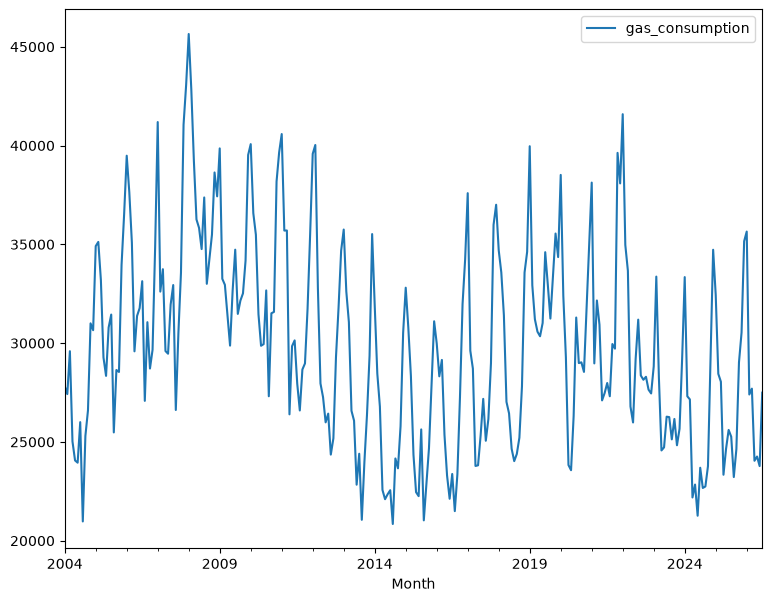

In [7]:
plt.rcParams["figure.figsize"] = (9,7)
Gas.plot()
plt.show()

A simple vista, el gráfico permite extraer las siguientes conclusiones preliminares:

* Componente estacional recurrente: La serie presenta una estacionalidad anual marcada y sistemática $(s = 12)$, caracterizada por picos pronunciados en los meses de invierno debido al uso de calefacción y valles en los meses estivales.
* Estabilidad en varianza: La amplitud de las oscilaciones estacionales parece mantenerse razonablemente proporcional y constante a lo largo de todo el periodo, sugiriendo en primera instancia ausencia de heterocedasticidad severa (aspecto que se contrastará formalmente más adelante).
* Ausencia de tendencia determinista global pero con cambios de régimen: No se aprecia una tendencia lineal única y sostenida a lo largo de los 22 años, sino alternancias de ciclos y tendencias locales condicionadas por el contexto macroeconómico y geopolítico:
  1. *Fase expansiva (2004–2008):* Crecimiento continuo de la demanda hasta el inicio de la crisis financiera global de 2008, punto donde se inicia una contracción prolongada.
  2. *Recuperación y crisis energética (2014–2022):* Incremento gradual de la actividad hasta 2022, año en el que el estallido del conflicto en Ucrania y la consiguiente escalada histórica de los precios del gas provocaron un notable shock a la baja en el consumo.
  3. *Etapa reciente (2024–2026):* Rebote paulatino de la demanda, aunque sujeta a la volatilidad e incertidumbre geopolítica internacional.

La presencia simultánea de estacionalidad anual y oscilaciones de media en el tiempo anticipa la necesidad de aplicar diferenciación regular y estacional para transformar la serie en un proceso estacionario.


## Modelización Box-Jenkins

Una vez exploradas las características descriptivas de la serie, se procede a aplicar la metodología de Box-Jenkins para determinar la estructura estocástica del proceso y seleccionar el modelo óptimo de predicción.

### 1. Identificación

#### 1.1 Estabilización de la varianza (Transformación de la serie)
El primer paso consiste en determinar si la serie es estacionaria en varianza (homocedástica) o si, por el contrario, la dispersión varía con el nivel medio exigiendo una transformación no lineal (como el logaritmo natural).

Para contrastarlo de manera rigurosa, se implementa el test de Bartlett, cuya hipótesis nula plantea la igualdad de varianzas entre los diferentes subperiodos anuales de la serie:
* $H_0$: Las submuestras anuales presentan la misma varianza $(\sigma_1^2 = \sigma_2^2 = \dots = \sigma_k^2$, homocedasticidad).
* $H_1$: Al menos un periodo presenta una varianza estadísticamente diferente (heterocedasticidad).

In [8]:
def bartlett_test(series):
    # Convertir a array plano de NumPy tipo float
    arr = series.values.astype(float)
    
    # Cortamos para que solo haya bloques completos de 12 meses
    n_years = len(arr) // 12
    y = arr[:n_years * 12]

    # Dividir en matriz de [años x 12 meses]
    matriz_nivel = y.reshape(n_years, 12)
    matriz_log = np.log(y).reshape(n_years, 12)
    
    #Test oficial de SciPy
    stat_nivel, p_nivel = bartlett(*matriz_nivel)
    stat_log, p_log = bartlett(*matriz_log)

    results = pd.DataFrame({
                'nivel': [stat_nivel, p_nivel],
                'log': [stat_log, p_log]
             }, index=['stat', 'prob'])
    print(results)

In [9]:
bartlett_test(Gas['gas_consumption'])

          nivel        log
stat  17.212923  20.488644
prob   0.698121   0.490527


El contraste arroja los siguientes resultados:
* Serie en niveles: estadístico $\chi^2 = 17.21$, con un $p$-valor asociado de $0.698$.
* Serie en logaritmos: estadístico $\chi^2 = 20.49$, con un $p$-valor asociado de $0.491$.

Dado que en la serie en niveles el $p$-valor supera con holgura el nivel de significación habitual $(\alpha = 0.05)$, no se rechaza la hipótesis nula de homocedasticidad. Por consiguiente, la variabilidad se mantiene estable en el tiempo y no se requiere la aplicación de logaritmos, permitiendo continuar el modelado directamente con la serie en sus unidades originales (GWh).

#### 1.2 Orden de integración y estacionariedad en media

Una vez validada la estabilidad de la varianza con la serie en niveles, el siguiente paso consiste en determinar el orden de integración del proceso, tanto regular $(d)$ como estacional $(D)$. El objetivo es identificar las diferencias necesarias para transformar la serie original en un proceso estacionario en media alrededor de un valor constante.

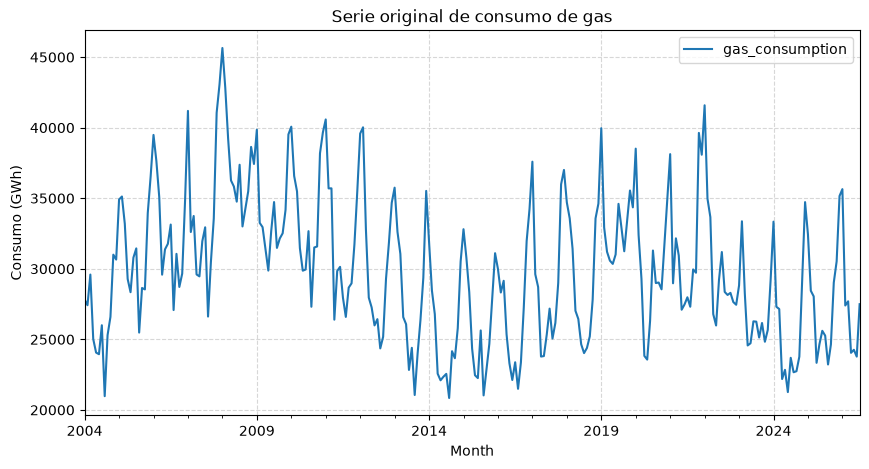

In [10]:
Gas.plot(figsize=(10, 5))
plt.title("Serie original de consumo de gas")
plt.ylabel("Consumo (GWh)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()  

La serie en niveles exhibe oscilaciones periódicas persistentes y cambios en su nivel medio a lo largo del tiempo, evidenciando una clara falta de estacionariedad. Para corroborar formalmente esta no estacionariedad se analizan a continuación las funciones de autocorrelación simple (ACF) y parcial (PACF).

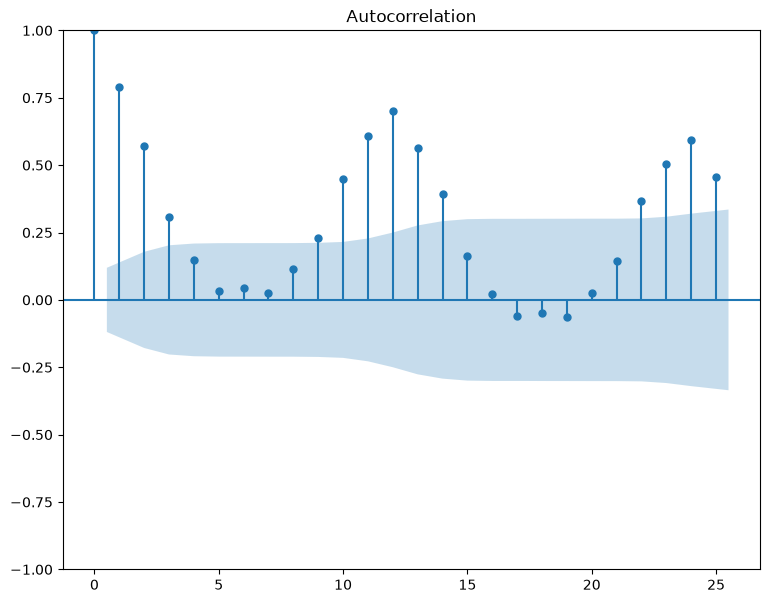

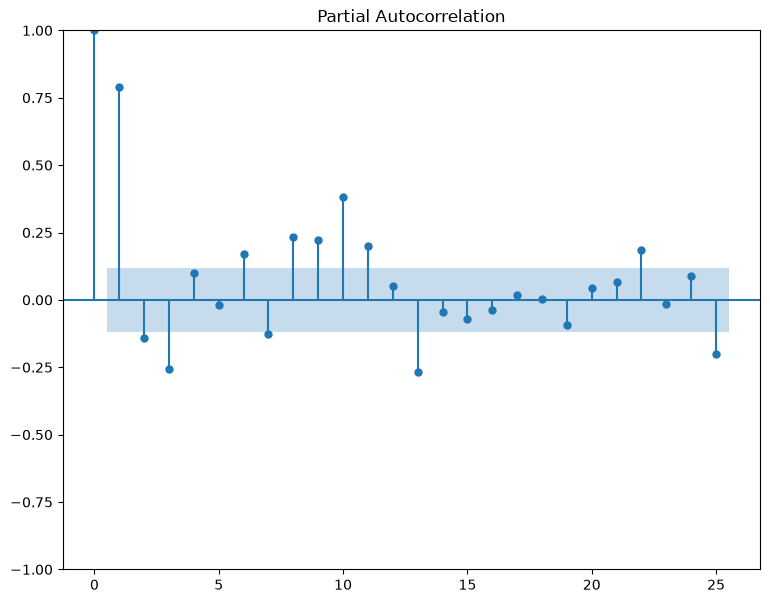

In [11]:
plot_acf(Gas.dropna(inplace = False))
plot_pacf(Gas.dropna(inplace = False))
plt.show()

El correlograma refleja claramente que la serie en niveles no es estacionaria: el ACF muestra una persistencia lenta en los primeros retardos y un patrón ondulante con picos muy pronunciados fuera de las bandas de confianza en los múltiplos de 12 (lags 12 y 24 con $\rho \approx 0.7$ y $0.6$), mientras que el PACF presenta un retardo 1 dominante $(\approx 0.8)$ junto a cortes significativos alrededor del ciclo anual. Este comportamiento confirma la necesidad imperativa de aplicar una diferencia estacional $(\Delta_{12})$ .

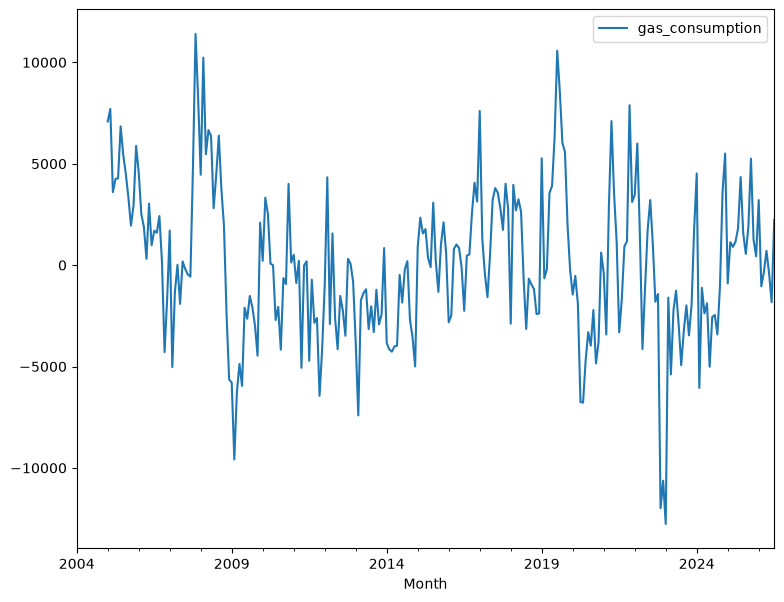

In [12]:
Gas_diff_12 = Gas.diff(periods = 12)
Gas_diff_12.plot()
plt.show()

Tras aplicar la diferencia estacional $(\Delta_{12})$, se elimina el patrón periódico cíclico anual. Sin embargo, persisten oscilaciones locales y cierta inercia en la serie que suscitan dudas sobre su estacionariedad en media. Para verificar formalmente la presencia de una raíz unitaria regular remanente, se aplica el contraste de Dickey-Fuller Aumentado (ADF).

In [13]:
def test_stationarity(timeseries, reg='c'):
    # Test Augmented Dickey-Fuller
    dftest = adfuller(timeseries, autolag='AIC', regression=reg)
    dfoutput = pd.Series(
        [dftest[0], dftest[1], int(dftest[2]), int(dftest[3])],
        index=['Test Statistic', 'p-value', '#Lags Used', 'Number of Observations Used']
    )
    for key, value in dftest[4].items():
        dfoutput[f'Critical Value ({key})'] = value
        
    print('Results of Dickey-Fuller Test:')
    # Mostrar con 4 decimales limpios
    print(dfoutput.apply(lambda x: f"{x:.4f}" if isinstance(x, float) else f"{x}"))

In [14]:
test_stationarity(Gas_diff_12.dropna(), reg = 'ct') # ct porque presenta tendencias todavía el grafico

Results of Dickey-Fuller Test:
Test Statistic                  -3.2309
p-value                          0.0784
#Lags Used                      16.0000
Number of Observations Used    242.0000
Critical Value (1%)             -3.9967
Critical Value (5%)             -3.4288
Critical Value (10%)            -3.1378
dtype: str


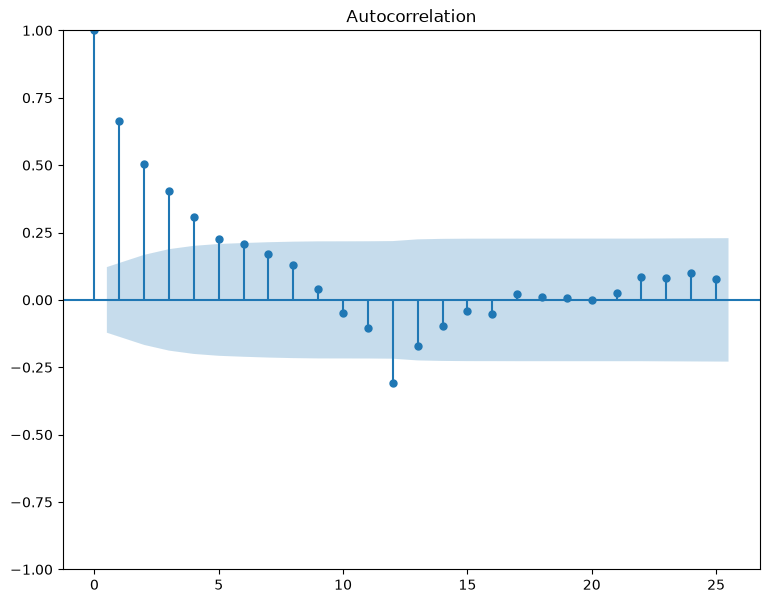

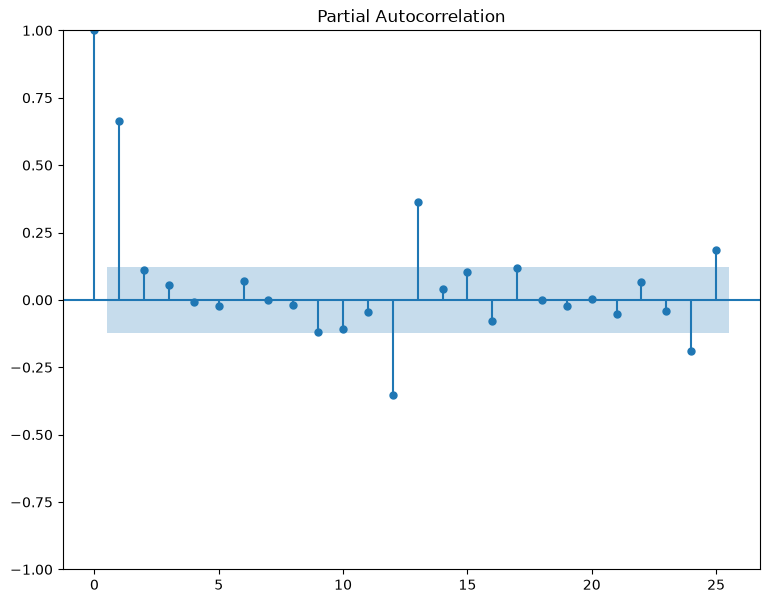

In [15]:
plot_acf(Gas_diff_12.dropna(inplace = False))
plot_pacf(Gas_diff_12.dropna(inplace = False))
plt.show()

Dado que el $p$-valor obtenido (0.0784) es superior al nivel de significación estándar del $5\%$ $(\alpha = 0.05)$, no se puede rechazar la hipótesis nula de raíz unitaria. La persistencia observada en los primeros retardos del correlograma ratifica la no estacionariedad en media regular, justificando formalmente la aplicación de una primera diferencia regular $(\Delta)$.

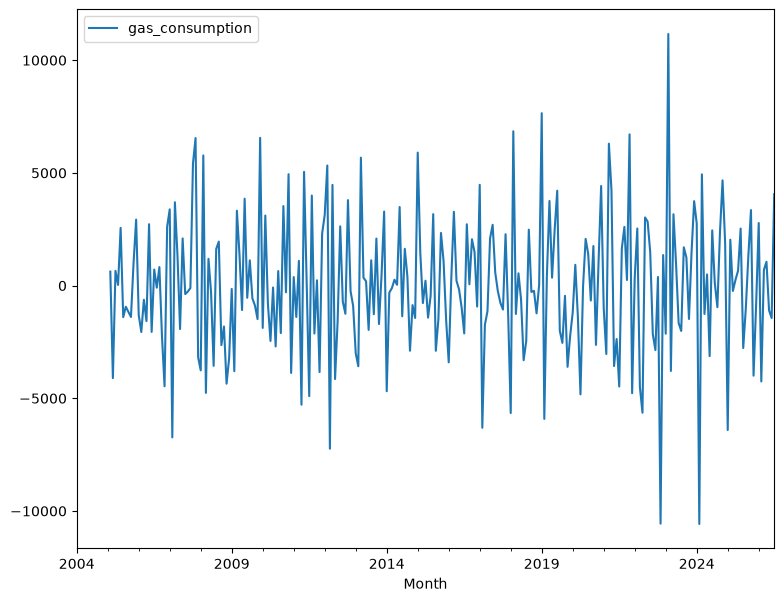

In [16]:
Gas_diff_1_12 = Gas_diff_12.diff(periods = 1)
Gas_diff_1_12.plot()
plt.show()

Tras aplicar la primera diferencia regular sobre la serie desestacionalizada $(\Delta \Delta_{12})$, la serie fluctúa de manera homogénea en torno a cero sin tendencias aparentes. A continuación, se aplica el test ADF con constante (`reg='c'`) para validar estadísticamente la estacionariedad.

In [17]:
test_stationarity(Gas_diff_1_12.dropna(), reg = 'c') # Porque ya no presenta tendencias

Results of Dickey-Fuller Test:
Test Statistic                  -6.8222
p-value                          0.0000
#Lags Used                      15.0000
Number of Observations Used    242.0000
Critical Value (1%)             -3.4577
Critical Value (5%)             -2.8736
Critical Value (10%)            -2.5732
dtype: str


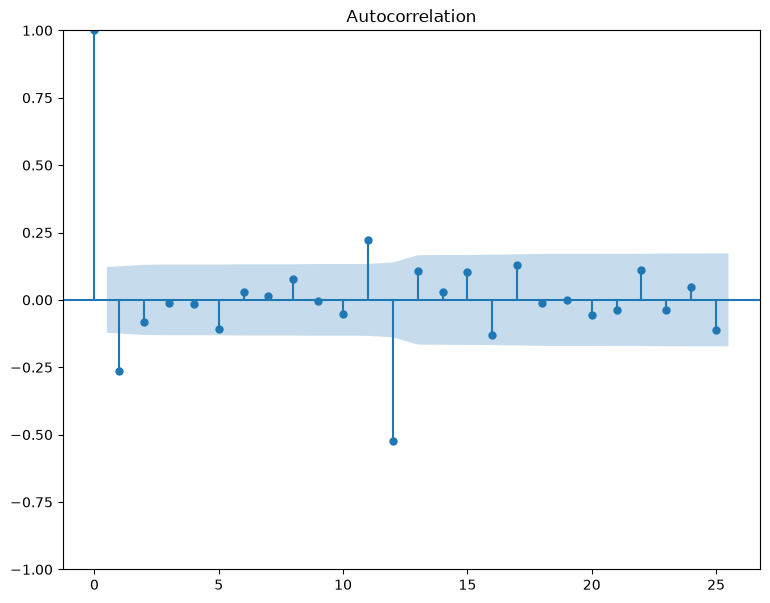

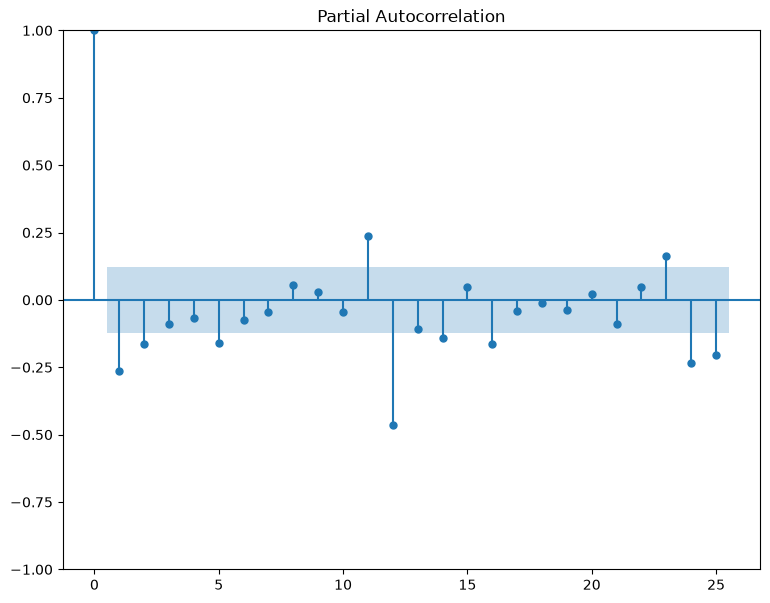

In [18]:
plot_acf(Gas_diff_1_12.dropna(inplace = False))
plot_pacf(Gas_diff_1_12.dropna(inplace = False))
plt.show()

Tras aplicar una diferencia regular y una estacional $(d = 1, D = 1)$, la serie alcanza la estacionariedad. El ACF muestra un corte nítido y negativo en el retardo 1 y un pico pronunciado en el retardo 12 que se anula en el retardo 24, señalando la presencia de componentes de medias móviles regular y estacional $(q = 1, Q = 1)$. Por su parte, el comportamiento amortiguado del PACF respalda la formulación del modelo canónico $\text{SARIMA}(0,1,1)(0,1,1)_{12}$ como hipótesis principal de Box-Jenkins, planteando variantes con términos autorregresivos ($p = 1$ o $P = 1$) para contrastar en la etapa de estimación.

### 2. Estimación

Como estrategia de selección rigurosa y conservadora frente a la ambigüedad observada en los retardos cruzados, se adopta el enfoque General a Específico. Se formula un modelo general de partida $\text{SARIMA}(1, 1, 1) \times (1, 1, 1)_{12}$ para capturar cualquier posible dinámica conjunta AR y MA. A partir de este ajuste inicial, se procede mediante eliminación hacia atrás (backward elimination), suprimiendo secuencialmente los coeficientes que resulten no estadísticamente significativo hasta alcanzar la estructura más parsimoniosa que minimice los criterios de información (AIC/BIC) y garantice residuos de ruido blanco.

Asimismo, complementamos la metodología clásica de Box-Jenkins incorporando una partición temporal en conjuntos de entrenamiento (train) y prueba (test). La validación fuera de muestra (out-of-sample) se estructuró reservando los últimos 12 meses disponibles (agosto de 2025 a julio de 2026) como conjunto de test, asignando los 259 meses previos (enero de 2004 a julio de 2025) al entrenamiento. Esta división garantiza evaluar el desempeño del modelo sobre un ciclo estacional completo $(s=12)$ sin desbalancear las métricas de error entre estaciones frías y cálidas. Asimismo, la amplia profundidad histórica del entrenamiento (más de 21 ciclos anuales) asegura la consistencia y convergencia de los parámetros estacionales, haciendo irrelevante que el corte temporal no coincida con el cierre de un año natural y reflejando con fidelidad el horizonte anual de planificación del sector gasista. Mientras que el enfoque tradicional evalúa los modelos exclusivamente dentro de muestra a partir de la significatividad de los coeficientes y criterios de información como AIC y BIC, la evaluación out-of-sample permite contrastar su capacidad predictiva real frente a datos no observados. De este modo, la selección final no depende únicamente de la parsimonia teórica, sino también de la minimización de métricas empíricas de error como el Error Porcentual Absoluto Medio (MAPE).

In [19]:
Gas_tr = Gas[:'2025-07-01']
Gas_tst = Gas['2025-08-01':]
Gas_tst

,gas_consumption
Month,
2025-08-01,23222
2025-09-01,24642
2025-10-01,29024
2025-11-01,30532
2025-12-01,35157
2026-01-01,35646
2026-02-01,27400
2026-03-01,27697
2026-04-01,24046


#### 2.1 Estimación del modelo general de partida: $\text{SARIMA}(1,1,1)(1,1,1)_{12}$

Siguiendo la estrategia de lo *General a lo Específico*, se ajusta inicialmente la especificación sobredimensionada que incorpora tanto términos autorregresivos como de medias móviles regulares y estacionales sobre el conjunto de entrenamiento (`Gas_tr`).

In [20]:
arima1 = SARIMAX(Gas_tr, 
                order = (1, 1, 1), 
                seasonal_order =(1, 1, 1, 12))
  
arima_1 = arima1.fit()
arima_1.summary()

C:\Users\diego\anaconda3\envs\ucm\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\diego\anaconda3\envs\ucm\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                    gas_consumption   No. Observations:                  259
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood               -2258.245
Date:                            Tue, 22 Sep 2026   AIC                           4526.489
Time:                                    19:38:02   BIC                           4544.016
Sample:                                01-01-2004   HQIC                          4533.546
                                     - 07-01-2025                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4117      0.205      2.010      0.044       0.010       0.813
ma.L1         -0.6339      0.171     -3.705      0.000      -0.969      -0.299
ar.S.L12       0.0575      0.061      0.948      0.343      -0.061       0.176
ma.S.L12      -0.8075      0.047    -17.198      0.000      -0.900      -0.715
sigma2      5.262e+06   4.15e+05     12.672      0.000    4.45e+06    6.08e+06
===================================================================================
Ljung-Box (L1) (Q):                   0.39   Jarque-Bera (JB):                12.96
Prob(Q):                              0.53   Prob(JB):                         0.00
Heteroskedasticity (H):               1.03   Skew:                             0.06
Prob(H) (two-sided):                  0.89   Kurtosis:                         4.12
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Del resumen de la estimación se extraen los siguientes contrastes de significación individual (con un nivel de significación del 5%):

* Términos de medias móviles: Resultan altamente significativos tanto en la parte regular (`ma.L1`, $p < 0.001$) como en la estacional (`ma.S.L12`, $p < 0.001$).
* Término autorregresivo regular (`ar.L1`): Es estadísticamente significativo al 5% ($p\text{-valor} = 0.044$, con estadístico $z = 2.010$).
* Término autorregresivo estacional (`ar.S.L12`): No resulta estadísticamente significativo ($p\text{-valor} = 0.343$, marcadamente superior a $\alpha = 0.05$).

Criterios de información obtenidos: AIC = 4526.49 y BIC = 4544.02.

Asimismo, el diagnóstico de los residuos confirma la estabilidad de la varianza: el test de heterocedasticidad de Harvey $(H)$ arroja un estadístico de 1.03, lo que garantiza que la dispersión de los errores se mantiene constante a lo largo de todo el horizonte muestral y valida el modelado de la serie en niveles.

A continuación, se define la función `eval_model` orientada a contrastar el comportamiento predictivo de cada especificación. La función calcula los pronósticos fuera de muestra sobre el conjunto de prueba (test), evalúa el error relativo mediante el MAPE (Mean Absolute Percentage Error) y ejecuta el test de Ljung-Box sobre los residuos hasta el retardo 12 para verificar la ausencia de correlación serial remanente.

In [21]:
def eval_model(model,tr,tst,name='Model',lags=12):
    lb = np.mean(sm.stats.acorr_ljungbox(model.resid, lags=lags, return_df=True).lb_pvalue)
    pred = model.forecast(steps=len(tst))
    fig1, ax = plt.subplots()
    ax.plot(tr, label='training')
    ax.plot(tst, label='test')
    ax.plot(pred, label='prediction')
    plt.legend(loc='upper left')
    tit = name + ":  LjungBox p-value --> " + str(lb) + "\n MAPE: " + str(round(mean_absolute_percentage_error(tst, pred)*100,2)) + "%"
    plt.title(tit)
    plt.ylabel('Consumo de gas')
    plt.xlabel('Date')
    plt.show()
    print(lb)

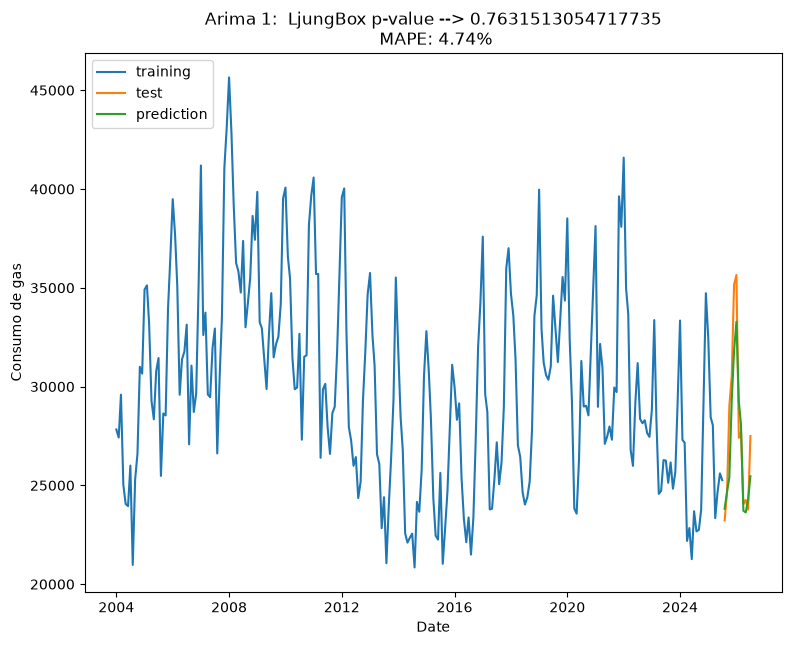

0.7631513054717735


In [22]:
eval_model(arima_1,Gas_tr,Gas_tst,'Arima 1')


Para esta especificación inicial $\text{SARIMA}(1,1,1)(1,1,1)_{12}$:
* Test de Ljung-Box: Al obtener un $p$-valor de $0.763$ $(p > 0.05)$, no se rechaza la hipótesis nula de incorrelación serial, confirmando que los residuos no presentan dependencia temporal significativa y se comportan como ruido blanco.
* Precisión predictiva: El modelo proyecta la trayectoria fuera de muestra con un $\text{MAPE} = 4.74\%$, demostrando una adecuada capacidad de generalización.

A pesar del buen rendimiento predictivo, el término estacional `ar.S.L12` no resultó significativo, por lo que se procede a estimar el siguiente modelo eliminando dicho parámetro.

#### 2.2 Estimación del modelo simplificado: $\text{SARIMA}(1,1,1)(0,1,1)_{12}$

In [23]:
arima2 = SARIMAX(Gas_tr, 
                order = (1, 1, 1), 
                seasonal_order =(0, 1, 1, 12))
  
arima_2 = arima2.fit()
arima_2.summary()

C:\Users\diego\anaconda3\envs\ucm\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\diego\anaconda3\envs\ucm\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                    gas_consumption   No. Observations:                  259
Model:             SARIMAX(1, 1, 1)x(0, 1, 1, 12)   Log Likelihood               -2258.438
Date:                            Tue, 22 Sep 2026   AIC                           4524.877
Time:                                    19:38:07   BIC                           4538.898
Sample:                                01-01-2004   HQIC                          4530.523
                                     - 07-01-2025                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4087      0.203      2.016      0.044       0.011       0.806
ma.L1         -0.6333      0.170     -3.735      0.000      -0.966      -0.301
ma.S.L12      -0.7681      0.043    -18.059      0.000      -0.851      -0.685
sigma2      5.284e+06   4.06e+05     13.007      0.000    4.49e+06    6.08e+06
===================================================================================
Ljung-Box (L1) (Q):                   0.32   Jarque-Bera (JB):                15.64
Prob(Q):                              0.57   Prob(JB):                         0.00
Heteroskedasticity (H):               1.02   Skew:                             0.06
Prob(H) (two-sided):                  0.94   Kurtosis:                         4.23
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Tras suprimir el término autorregresivo estacional (`ar.S.L12`), todos los coeficientes remanentes resultan estadísticamente significativos al $5\%$ (incluido el término autorregresivo regular `ar.L1` con $p = 0.044$). 

Además, se produce una reducción en los criterios de información penalizada:
* AIC: desciende de $4526.49$ a $4524.88$.
* BIC: se reduce de $4544.02$ a $4538.90$.

El diagnóstico de los residuos también confirma la estabilidad de la varianza: el test de heterocedasticidad de Harvey $(H)$ arroja un estadístico de 1.02, lo que garantiza que la dispersión de los errores se mantiene constante a lo largo de todo el horizonte muestral y valida el modelado de la serie en niveles.

Esta mejora ratifica que la eliminación del parámetro innecesario genera una especificación más eficiente dentro de muestra. A continuación, se evalúa su desempeño fuera de muestra.

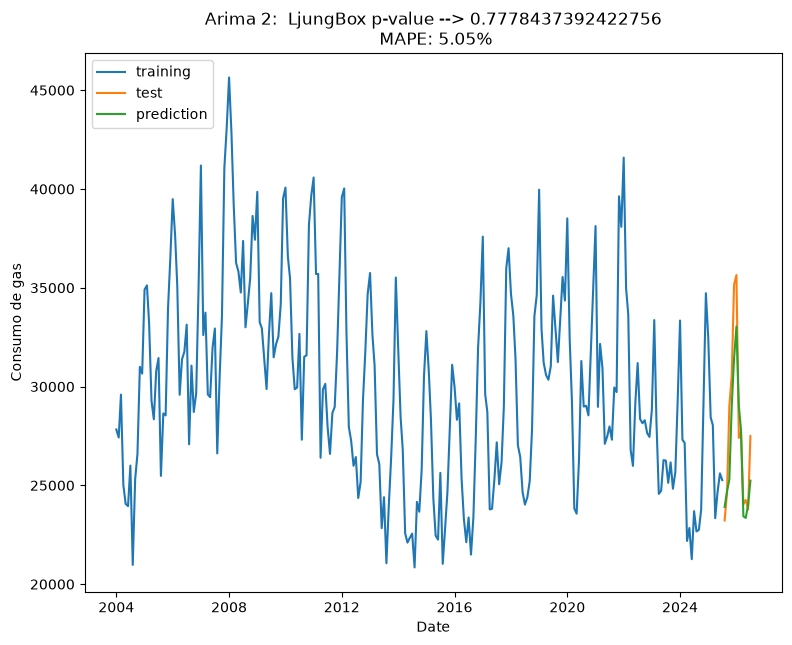

0.7778437392422756


In [24]:
eval_model(arima_2,Gas_tr,Gas_tst,'Arima 2')


Del análisis predictivo y de diagnóstico del modelo $\text{SARIMA}(1,1,1)(0,1,1)_{12}$ se desprende:

* Incorrelación residual: Con un $p$-valor de $0.7778$ en el test de Ljung-Box $(p > 0.05)$, no se rechaza la hipótesis nula de ausencia de autocorrelación, corroborando que las perturbaciones se comportan como ruido blanco.
* Error fuera de muestra: El error porcentual medio se sitúa en un $\text{MAPE} = 5.05\%$, lo que supone un ligero empeoramiento predictivo respecto a la especificación anterior (4.74\%)

Dado que el coeficiente autorregresivo regular (ar.L1) se encuentra al límite del umbral de significación $(p = 0.044)$ y considerando que el análisis preliminar de la función de autocorrelación parcial (PACF) no mostraba retardos AR claros tras la diferenciación, se procede a estimar el modelo: $\text{SARIMA}(0,1,1)(0,1,1)_{12}$ 

#### 2.3 Estimación del modelo de propuesta inicial: $\text{SARIMA}(0,1,1)(0,1,1)_{12}$

In [25]:
arima3 = SARIMAX(Gas_tr, 
                order = (0, 1, 1), 
                seasonal_order =(0, 1, 1, 12))
  
arima_3 = arima3.fit()
arima_3.summary()

C:\Users\diego\anaconda3\envs\ucm\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\diego\anaconda3\envs\ucm\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                    gas_consumption   No. Observations:                  259
Model:             SARIMAX(0, 1, 1)x(0, 1, 1, 12)   Log Likelihood               -2259.532
Date:                            Tue, 22 Sep 2026   AIC                           4525.064
Time:                                    19:38:10   BIC                           4535.580
Sample:                                01-01-2004   HQIC                          4529.299
                                     - 07-01-2025                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.2390      0.055     -4.355      0.000      -0.347      -0.131
ma.S.L12      -0.7769      0.040    -19.418      0.000      -0.855      -0.699
sigma2      5.338e+06   4.01e+05     13.318      0.000    4.55e+06    6.12e+06
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                20.37
Prob(Q):                              0.93   Prob(JB):                         0.00
Heteroskedasticity (H):               1.05   Skew:                             0.08
Prob(H) (two-sided):                  0.81   Kurtosis:                         4.40
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

En esta especificación $\text{SARIMA}(0,1,1)(0,1,1)_{12}$:
* Todos los coeficientes resultan estadísticamente significativos con un nivel de confianza superior al $99\%$ ($p\text{-valor} < 0.001$).
* Aunque el AIC experimenta un leve incremento respecto al modelo 2 (de $4524.88$ a $4525.06$), el criterio bayesiano alcanza su valor mínimo global: $\text{BIC} = 4535.58$ (frente a los $4538.90$ del Modelo 2).

Por último, par este tercer modelo el diagnóstico de los residuos tamnién confirma la estabilidad de la varianza: el test de heterocedasticidad de Harvey $(H)$ arroja un estadístico de 1.05, lo que garantiza que la dispersión de los errores se mantiene constante a lo largo de todo el horizonte muestral y valida el modelado de la serie en niveles.

El BIC penaliza con mayor severidad la inclusión de parámetros adicionales, confirmando que prescindir del término autorregresivo regular simplifica la estructura del modelo sin incurrir en pérdida de capacidad explicativa dentro de muestra. A continuación, se evalúa su desempeño fuera de muestra.

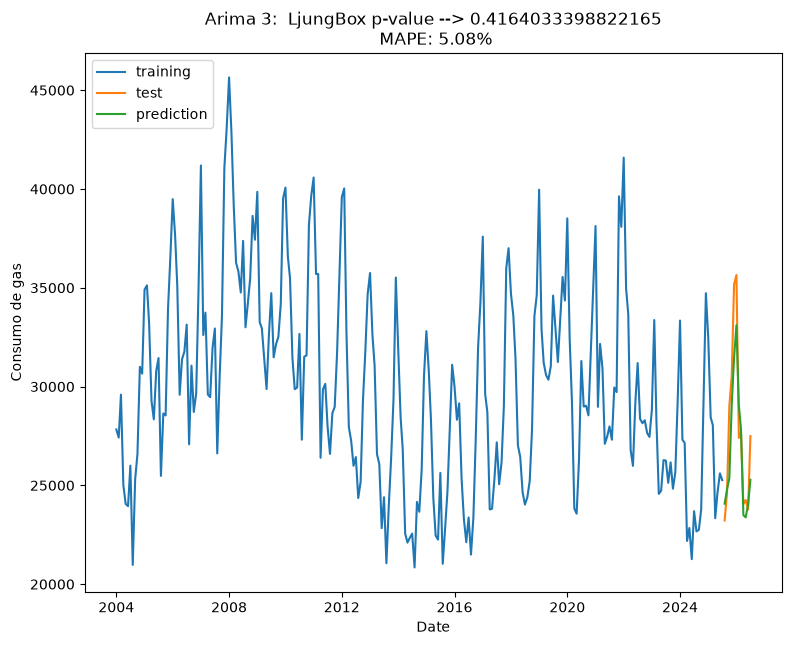

0.4164033398822165


In [26]:
eval_model(arima_3,Gas_tr,Gas_tst,'Arima 3')

Del análisis predictivo y de evaluación del Modelo 3 se concluye:

* Incorrelación serial: Con un $p$-valor conjunto de $0.4164$ en el contraste de Ljung-Box $(p > 0.05)$, no se rechaza la hipótesis nula de ausencia de autocorrelación, garantizando que los residuos no presentan dependencia temporal sistemática y se comportan como ruido blanco.
* Capacidad predictiva fuera de muestra: Registra un $\text{MAPE} = 5.08\%$, una precisión prácticamente idéntica a la del Modelo 2 $(5.05\%)$, evidenciando que la omisión del parámetro autorregresivo regular apenas tiene impacto en la precisión predictiva fuera de muestra.

Con el propósito de validar de manera exhaustiva las especificaciones analizadas manualmente, se ejecuta a continuación el algoritmo `auto_arima` de *pmdarima* mediante optimización paso a paso (*stepwise*) bajo el criterio AIC.

In [27]:
# Ajustamos modelo arima step-wise con métrica AIC para la serie de vuelos
arima_auto = pm.auto_arima(Gas_tr, start_p=1, start_q=1,
                      test='adf',       # use adftest to find optimal 'd'
                      max_p=5, max_q=5, # maximum p and q
                      m=12,              # frequency of series
                      d=1,           # let model determine 'd'
                      seasonal=True,   # No Seasonality
                      #start_P=None, 
                      D=1, 
                      trace=True,
                      error_action='ignore',  
                      suppress_warnings=True, 
                      stepwise=True)

print(arima_auto.summary())

Performing stepwise search to minimize aic


 ARIMA(1,1,1)(1,1,1)[12]             : AIC=4526.489, Time=4.03 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=4650.788, Time=0.13 sec


 ARIMA(1,1,0)(1,1,0)[12]             : AIC=4587.762, Time=0.59 sec


 ARIMA(0,1,1)(0,1,1)[12]             : AIC=4525.064, Time=1.86 sec
 ARIMA(0,1,1)(0,1,0)[12]             : AIC=4634.241, Time=0.19 sec


 ARIMA(0,1,1)(1,1,1)[12]             : AIC=4526.580, Time=4.84 sec


...

 ARIMA(1,1,2)(0,1,1)[12]             : AIC=4528.987, Time=6.21 sec


 ARIMA(0,1,2)(0,1,1)[12]             : AIC=4525.656, Time=3.87 sec


 ARIMA(2,1,0)(0,1,1)[12]             : AIC=4526.446, Time=2.76 sec


 ARIMA(2,1,2)(0,1,1)[12]             : AIC=inf, Time=6.84 sec


 ARIMA(1,1,1)(0,1,1)[12] intercept   : AIC=4528.595, Time=5.06 sec

Best model:  ARIMA(1,1,1)(0,1,1)[12]          
Total fit time: 84.215 seconds
                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                  259
Model:             SARIMAX(1, 1, 1)x(0, 1, 1, 12)   Log Likelihood               -2258.438
Date:                            Tue, 22 Sep 2026   AIC                           4524.877
Time:                                    19:39:35   BIC                           4538.898
Sample:                                01-01-2004   HQIC                          4530.523
                                     - 07-01-2025                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------

#### 2.4 Comparativa final y selección del modelo óptimo

El procedimiento automatizado `auto_arima` selecciona como especificación preferida bajo la minimización estricta de AIC el modelo $\text{SARIMA}(1,1,1)(0,1,1)_{12}$ (idéntico a nuestro Modelo 2). 

No obstante, al confrontar de forma multidimensional las tres especificaciones candidatas:

1. $\text{SARIMA}(1,1,1)(1,1,1)_{12}$ (Modelo 1): Aunque obtiene el menor error fuera de muestra $(\text{MAPE} = 4.74\%)$, incluye un parámetro estacional (`ar.S.L12`) no significativo $(p = 0.343)$, vulnerando el criterio de significación individual.
2. $\text{SARIMA}(1,1,1)(0,1,1)_{12}$ (Modelo 2): Minimiza el AIC $(4524.88)$ y logra un $\text{MAPE} = 5.05\%$, pero presenta un criterio de información bayesiano superior $(\text{BIC} = 4538.90)$ y su coeficiente autorregresivo regular (`ar.L1`) se encuentra al límite del umbral de rechazo $(p = 0.044)$.
3. $\text{SARIMA}(0,1,1)(0,1,1)_{12}$ (Modelo 3 ): Todos sus parámetros son altamente significativos $(p < 0.001)$, su capacidad predictiva es prácticamente indistinguible del Modelo 2 $(\text{MAPE} = 5.08\%)$ y minimiza el criterio de información bayesiano $(\text{BIC} = 4535.58)$.

Bajo el principio de parsimonia, que prioriza la estructura más simple y robusta ante desempeños predictivos equivalentes, se selecciona formalmente el Modelo 3: **SARIMA(0, 1, 1)(0, 1, 1)₁₂** para proceder a la diagnosis exhaustiva de los residuos y a la generación de las predicciones definitivas.

**Formulación teórica:**

$$(1 - B)(1 - B^{12}) y_t = (1 + \theta_1 B)(1 + \Theta_1 B^{12}) \varepsilon_t$$

Donde:
* $B$ es el operador de retardo $(B^k y_t = y_{t-k})$.
* $(1 - B)(1 - B^{12})$ representa el filtro de doble diferenciación aplicada (regular y estacional).
* $\theta_1$ es el parámetro de media móvil regular $(\text{MA}_1)$.
* $\Theta_1$ es el parámetro de media móvil estacional $(\text{SMA}_{12})$.
* $\varepsilon_t$ representa las perturbaciones estocásticas o ruido blanco $(\varepsilon_t \sim \text{iid }(0, \sigma^2))$.

### 3. Diagnosis del Modelo Seleccionado

Previamente a la generación de predicciones definitivas, se somete el modelo $\text{SARIMA}(0,1,1)(0,1,1)_{12}$ a una etapa exhaustiva de diagnosis residual para comprobar si las perturbaciones estimadas satisfacen las propiedades de un proceso de ruido blanco:

1. Media nula $(\mu_\varepsilon \approx 0)$: Garantiza la insesgadez de las estimaciones.
2. Incorrelación serial: Se evalúa de manera global considerando el $p$-valor promedio del test de Ljung-Box a lo largo de los retardos analizados, sirviendo como métrica agregada de estabilidad antes de corroborar visualmente la ausencia de picos significativos en el correlograma (ACF).
3. Normalidad: Se contrasta formalmente mediante el test de Jarque-Bera ($H_0$: distribución normal).
4. Estacionariedad: Se valida mediante el contraste ADF sobre los residuos ($H_0$: existencia de raíz unitaria).
5. Homocedasticidad condicional: Se implementa el test ARCH-LM de Engle ($H_0$: ausencia de efectos ARCH). Siguiendo las recomendaciones metodológicas para modelos SARIMA, el contraste se evalúa omitiendo los primeros 13 periodos (`residuals[13:]`), ya que corresponden a la fase de inicialización asociada a la diferenciación conjunta regular y estacional $(d=1, D=1, s=12)$.

A continuación, se ejecuta la rutina `residcheck` para centralizar tanto la diagnosis gráfica como los contrastes formales de hipótesis.

In [41]:
# Función para evaluar residuos a través de contrastes de hipótesis
def residcheck(residuals, lags):
    """
    Function to check if the residuals are white noise. Ideally the residuals should be uncorrelated, zero mean, 
    constant variance and normally distributed. First two are must, while last two are good to have. 
    If the first two are not met, we have not fully captured the information from the data for prediction. 
    Consider different model and/or add exogenous variable. 
        
    If Ljung Box test shows p> 0.05, the residuals as a group are white noise. Some lags might still be significant. 
        
    Lags should be min(2*seasonal_period, T/5)
        
    plots from: https://tomaugspurger.github.io/modern-7-timeseries.html
        
    """
    resid_mean = np.mean(residuals)
    lj_p_val = np.mean(sm.stats.acorr_ljungbox(x=residuals, lags=lags).lb_pvalue)
    norm_p_val =  stats.jarque_bera(residuals)[1]
    adfuller_p = adfuller(residuals)[1]
    arch_p_val = het_arch(residuals[13:], nlags=lags)[1]
    
  
    fig = plt.figure(figsize=(10,8))
    layout = (2, 2)
    ts_ax = plt.subplot2grid(layout, (0, 0), colspan=2);
    acf_ax = plt.subplot2grid(layout, (1, 0));
    kde_ax = plt.subplot2grid(layout, (1, 1));
    
    residuals.plot(ax=ts_ax)
    plot_acf(residuals, lags=lags, ax=acf_ax);
    sns.kdeplot(residuals);
    #[ax.set_xlim(1.5) for ax in [acf_ax, kde_ax]]
    sns.despine()
    plt.tight_layout();
    plt.show()
    print("** Mean of the residuals: ", np.around(resid_mean,2))
        
    print("\n** Ljung Box Test, p-value:", np.around(lj_p_val,4), 
        "(>0.05, Uncorrelated)" if (lj_p_val > 0.05) else "(<0.05, Correlated)")
        
    print("\n** Jarque Bera Normality Test, p_value:", np.around(norm_p_val,4),
        "(>0.05, Normal)" if (norm_p_val>0.05) else "(<0.05, Not-normal)")
        
    print("\n** AD Fuller, p_value:", np.around(adfuller_p,4), 
        "(>0.05, Non-stationary)" if (adfuller_p > 0.05) else "(<0.05, Stationary)")
    
    print("\n** Test de ARCH-LM, p_value:",  np.around(arch_p_val,4),
          "(<0.05, heterocedastic)" if (arch_p_val < 0.05) else "(>0.05, homocedastic)")
   
    return ts_ax, acf_ax, kde_ax   
 

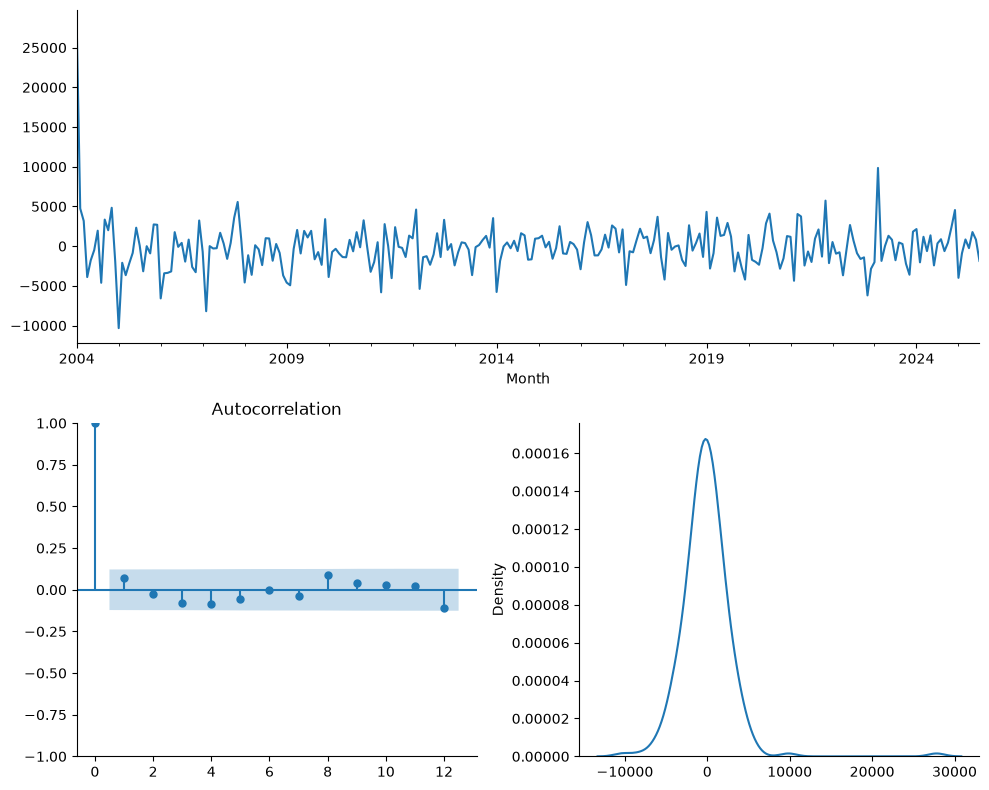

** Mean of the residuals:  -157.72

** Ljung Box Test, p-value: 0.4164 (>0.05, Uncorrelated)

** Jarque Bera Normality Test, p_value: 0.0 (<0.05, Not-normal)

** AD Fuller, p_value: 0.0 (<0.05, Stationary)

** Test de ARCH-LM, p_value: 0.3645 (>0.05, homocedastic)


(<Axes: xlabel='Month'>,
 <Axes: title={'center': 'Autocorrelation'}>,
 <Axes: ylabel='Density'>)

In [42]:
residcheck(arima_3.resid, 12)

Los resultados indican que la media de los residuos es de $-157.72\text{ GWh}$, un valor prácticamente despreciable en comparación con la magnitud del consumo medio mensual (superior a los $30.000\text{ GWh}$), confirmando la insesgadez del ajuste. Asimismo, el test de Dickey-Fuller Aumentado $(p\text{-valor} = 0.000)$ corrobora que las perturbaciones son estrictamente estacionarias en media.

Por su parte, el $p$-valor promedio del test de Ljung-Box $(0.4164 > 0.05)$ indica que los residuos no presentan autocorrelación serial significativa al nivel del $5\%$. Aunque el contraste de Jarque-Bera $(p\text{-valor} = 0.000)$ rechaza la hipótesis de normalidad, esto no invalida el modelo: se sigue garantizando la condición de ruido blanco débil (media cero, incorrelación temporal y varianza constante), suficiente para asegurar la validez asintótica de las estimaciones y las propiedades óptimas de los pronósticos.

Por último, el test ARCH-LM $(p\text{-valor} = 0.3645 > 0.05)$, evaluado descartando los primeros 13 periodos para mitigar el efecto transitorio de inicialización derivado de la diferenciación estacional y regular $(d=1, D=1, s=12)$, ratifica la homocedasticidad condicional de las perturbaciones. Esta estabilidad dinámica complementa la homocedasticidad global demostrada previamente en el resumen, validando por completo la hipótesis de varianza constante requerida en el proceso de perturbación.

A continuación, se evalúan en detalle los correlogramas (ACF y PACF) y la tabla de contrastes de Ljung-Box retardo a retardo para verificar la ausencia individual de dependencia serial.

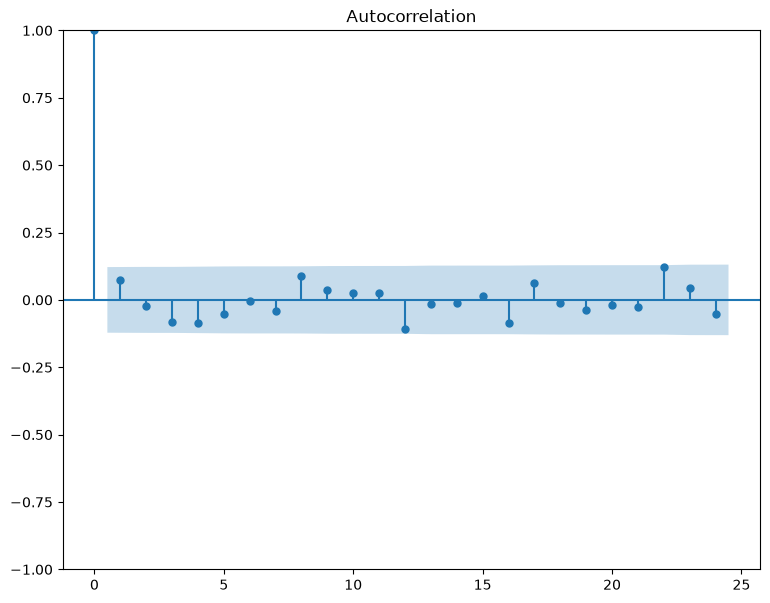

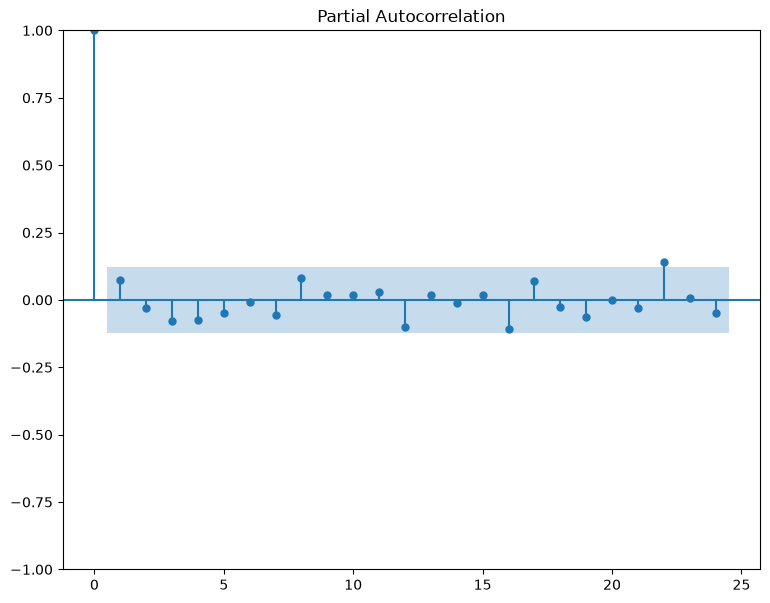

In [30]:
plot_acf(arima_3.resid,lags=24)
plt.show()
plot_pacf(arima_3.resid,lags=24,method='ywm')
plt.show()

La inspección visual de las funciones de autocorrelación simple (ACF) y parcial (PACF) de los residuos a lo largo de 24 retardos (dos ciclos anuales completos) ratifica la ausencia de correlación serial. La práctica totalidad de las autocorrelaciones se sitúa holgadamente dentro de las bandas de confianza del $95\%$, sin mostrar patrones sistemáticos en los retardos regulares ni en los estacionales $(s = 12, 24)$. La fluctuación marginal observada en el retardo 22 carece de interpretación económica y responde a la variabilidad muestral esperable bajo un nivel de confianza del $95\%$.

In [31]:
sm.stats.acorr_ljungbox(arima_3.resid, lags=12, return_df=True)

,lb_stat,lb_pvalue
1,1.373233,0.241257
2,1.513724,0.469136
3,3.216854,0.359384
4,5.151276,0.272125
5,5.932744,0.312818
6,5.935011,0.430509
7,6.368787,0.497407
8,8.408233,0.394642
9,8.802688,0.455684
10,8.999089,0.532190


Asimismo, al evaluar la evolución secuencial del test de Ljung-Box a lo largo de los 12 retardos del ciclo anual, se constata que los $p$-valores superan en todo momento el nivel de significación del $5\%$ $(\alpha = 0.05)$, oscilando entre $0.241$ y $0.608$. 

Esta evidencia empírica confirma la ausencia de autocorrelación serial acumulada paso a paso, ratificando de manera concluyente que las perturbaciones del modelo $\text{SARIMA}(0,1,1)(0,1,1)_{12}$ constituyen un proceso de ruido blanco. Cumplidos satisfactoriamente todos los criterios de diagnosis, el modelo queda plenamente validado para la fase final de predicción y análisis de escenarios.

## 4. Predicción y Proyecciones Futuras

### 4.1 Calibración del modelo sobre la muestra completa

Una vez validada la capacidad predictiva y la bondad de ajuste del modelo $\text{SARIMA}(0,1,1)(0,1,1)_{12}$, se procede a su reestimación incorporando la totalidad de la muestra histórica disponible (enero de 2004 a julio de 2026, $T = 271$ observaciones). De este modo, se aprovecha toda la información reciente del conjunto de prueba para calibrar los parámetros con la máxima eficiencia estadística antes de generar las trayectorias prospectivas.

In [32]:
arima_final = SARIMAX(Gas, 
                order = (0, 1, 1), 
                seasonal_order =(0, 1, 1, 12))
  
arima_final = arima_final.fit()
arima_final.summary()

C:\Users\diego\anaconda3\envs\ucm\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\diego\anaconda3\envs\ucm\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                    gas_consumption   No. Observations:                  271
Model:             SARIMAX(0, 1, 1)x(0, 1, 1, 12)   Log Likelihood               -2368.037
Date:                            Tue, 22 Sep 2026   AIC                           4742.074
Time:                                    19:39:42   BIC                           4752.733
Sample:                                01-01-2004   HQIC                          4746.360
                                     - 07-01-2026                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.2449      0.054     -4.559      0.000      -0.350      -0.140
ma.S.L12      -0.7834      0.039    -20.308      0.000      -0.859      -0.708
sigma2      5.268e+06   3.88e+05     13.590      0.000    4.51e+06    6.03e+06
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                19.49
Prob(Q):                              0.96   Prob(JB):                         0.00
Heteroskedasticity (H):               0.95   Skew:                             0.06
Prob(H) (two-sided):                  0.82   Kurtosis:                         4.34
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

La estimación sobre la muestra completa ratifica plenamente la solidez del modelo:

* Tanto el parámetro de medias móviles regular (`ma.L1 = -0.2449`) como el estacional (`ma.S.L12 = -0.7834`) se mantienen estables y resultan altamente significativos $(p\text{-valor} < 0.001)$.
* Los diagnósticos globales continúan respaldando la idoneidad del ajuste, con un estadístico de Ljung-Box en el primer retardo que arroja un $p$-valor de $0.96$, evidenciando ausencia de correlación residual inmediata.

#### Ecuación estimada definitiva ($T = 271$, 2004–2026): 

$$(1 - B)(1 - B^{12}) y_t = (1 - 0.2449 B)(1 - 0.7834 B^{12}) \hat{\varepsilon}_t$$

Forma desarrollada para el cálculo recursivo de valores en niveles:

$$y_t = y_{t-1} + y_{t-12} - y_{t-13} + \hat{\varepsilon}_t - 0.2449 \hat{\varepsilon}_{t-1} - 0.7834 \hat{\varepsilon}_{t-12} + 0.1919 \hat{\varepsilon}_{t-13}$$

A continuación, se realiza una verificación de diagnóstico rápida sobre los residuos de este modelo final para corroborar que preservan las condiciones de ruido blanco demostradas previamente.

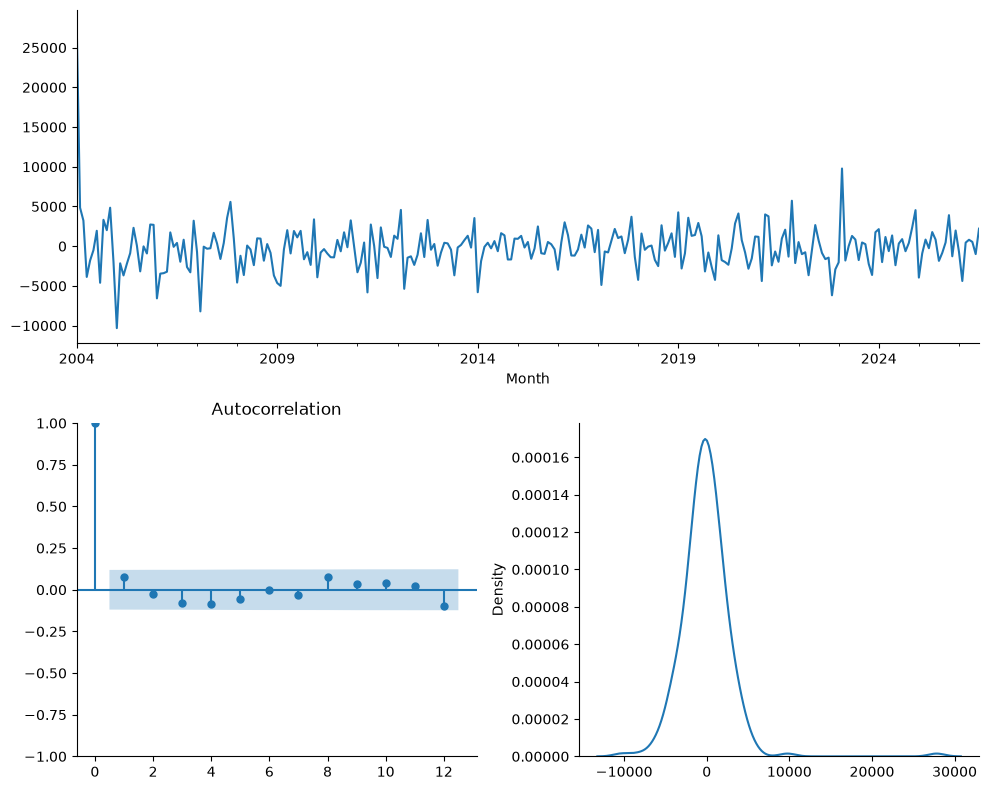

** Mean of the residuals:  -148.48

** Ljung Box Test, p-value: 0.4046 (>0.05, Uncorrelated)

** Jarque Bera Normality Test, p_value: 0.0 (<0.05, Not-normal)

** AD Fuller, p_value: 0.0 (<0.05, Stationary)

** Test de ARCH-LM, p_value: 0.3632 (>0.05, homocedastic)


(<Axes: xlabel='Month'>,
 <Axes: title={'center': 'Autocorrelation'}>,
 <Axes: ylabel='Density'>)

In [43]:
residcheck(arima_final.resid,12)

Tras reestimar el modelo definitivo sobre la muestra completa (2004–2026), el diagnóstico residual corrobora la estabilidad de la especificación. Los errores mantienen una media prácticamente nula $(-148.48\text{ GWh})$, estacionariedad estricta $(p = 0.000)$, ausencia de correlación serial (Ljung-Box, $p = 0.4046 > 0.05$) y homocedasticidad condicional (ARCH-LM, $p = 0.3632 > 0.05$). Al verificarse que los residuos satisfacen plenamente las propiedades de ruido blanco débil tras incorporar el último ciclo anual, el modelo queda definitivamente calibrado y listo para generar las proyecciones prospectivas.

### 4.2 Predicciones

In [34]:
pred = arima_final.get_forecast(steps = 12)
df_pred = pred.summary_frame(alpha = 0.05).round(2)
df_pred.columns = ['Forecast', 'SE', '95% LB', '95% UB']
df_pred


,Forecast,SE,95% LB,95% UB
2026-08-01,25213.68,2295.12,20715.33,29712.03
2026-09-01,26100.59,2876.00,20463.73,31737.45
2026-10-01,27512.01,3357.85,20930.74,34093.29
2026-11-01,30764.07,3778.75,23357.85,38170.29
2026-12-01,33599.32,4157.26,25451.25,41747.40
2027-01-01,35019.72,4504.06,26191.92,43847.52
2027-02-01,30068.14,4826.01,20609.33,39526.95
2027-03-01,29172.68,5127.79,19122.40,39222.95
2027-04-01,24973.47,5412.76,14364.66,35582.29
2027-05-01,24919.41,5683.47,13780.02,36058.80


En la tabla anterior se presentan las proyecciones puntuales mensuales junto con su error estándar (`SE`) y los intervalos de confianza del 95% (`95% LB` y `95% UB`) para un horizonte prospectivo de 12 meses (agosto de 2026 a julio de 2027).

La trayectoria estimada replica con fidelidad la dinámica estacional característica de la demanda gasista:
* Se proyecta un incremento sostenido a partir del otoño hasta alcanzar el pico invernal en enero de 2027 (35.019,72 GWh).
* Posteriormente, se registra una contracción paulatina hacia los valles de primavera-verano (en torno a los 24.900 GWh).
* De acuerdo con la teoría de procesos integrados $(d=1, D=1)$, el error estándar de predicción (`SE`) se expande a medida que aumenta el horizonte temporal (desde $2.295,12$ en el primer mes hasta $6.189,46$ en el mes 12), reflejando la acumulación de incertidumbre en las estimaciones a medio plazo.

### 4.3 Análisis e interpretación de las proyecciones

A continuación, se representa gráficamente el pronóstico integrando las bandas de confianza del 95% y contrastándolo con el histórico de los últimos 5 años para evaluar su coherencia estructural.

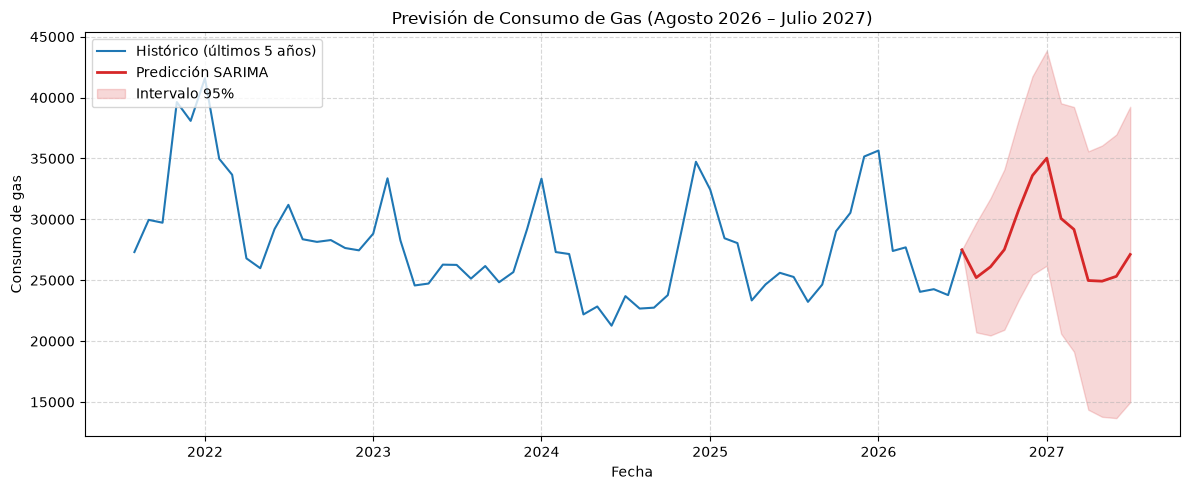

In [35]:
# 1. Crear una pequeña serie puente con el último punto real + la predicción
ultimo_punto = Gas['gas_consumption'].iloc[-1:]  # Julio 2026
pred_continua = pd.concat([ultimo_punto, df_pred['Forecast']])

# Para la banda de confianza también incluimos el último punto (con ancho cero al inicio)
ci_lower_continua = pd.concat([ultimo_punto, df_pred['95% LB']])
ci_upper_continua = pd.concat([ultimo_punto, df_pred['95% UB']])

# 2. Graficar con zoom en los últimos 5 años (por ejemplo, últimos 36 meses)
plt.figure(figsize=(12, 5))

# Histórico reciente
plt.plot(Gas.index[-60:], Gas['gas_consumption'].iloc[-60:], label='Histórico (últimos 5 años)', color='#1f77b4', lw=1.5)

# Predicción perfectamente unida
plt.plot(pred_continua.index, pred_continua.values, label='Predicción SARIMA', color='#d62728', lw=2)

# Sombra conectada desde el último valor real
plt.fill_between(
    ci_lower_continua.index,
    ci_lower_continua.values,
    ci_upper_continua.values,
    color='#d62728',
    alpha=0.18,
    label='Intervalo 95%'
)

plt.title("Previsión de Consumo de Gas (Agosto 2026 – Julio 2027)")
plt.ylabel('Consumo de gas')
plt.xlabel('Fecha')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

El gráfico anterior ilustra el empalme entre la trayectoria observada en los últimos 5 años y las proyecciones puntuales acompañadas de sus bandas de incertidumbre al 95%:

* Consistencia estacional: El modelo $\text{SARIMA}(0,1,1)(0,1,1)_{12}$ replica fielmente el ciclo intra-anual de la demanda gasista, anticipando el inicio del repunte térmico en otoño, un pico invernal centrado en enero de 2027 y la posterior estabilización estival en niveles similares a los ejercicios precedentes.
* Comportamiento del nivel medio: En consonancia con la ausencia de una deriva determinista en la especificación integrada, la previsión no proyecta variaciones tendenciales explosivas, sino una consolidación moderada de los volúmenes de consumo en torno a los promedios observados entre 2024 y 2026.
* Banda de incertidumbre: Como es característico en los procesos no estacionarios con doble orden de integración $(d=1, D=1)$, el abanico del intervalo de confianza se expande progresivamente hacia el final del horizonte, delimitando un rango de variación entre los $14.000$ y los $43.000\text{ GWh}$ para cubrir escenarios extremos de volatilidad climática o perturbaciones en los mercados energéticos.

## 5. Conclusiones

La modelización econométrica de la demanda de gas natural en España a partir de las series históricas de CORES confirma la idoneidad empírica de la metodología Box-Jenkins para capturar la dinámica estacional del sistema energético. La estabilidad inicial de la varianza en niveles (contrastada mediante el test de Bartlett, $p > 0.05$) descartó transformaciones no lineales, mientras que la combinación de una diferenciación estacional $(D=1, s=12)$ y una regular $(d=1)$ garantizó la estacionariedad estricta de la serie según los contrastes Dickey-Fuller Aumentado.

Siguiendo una estrategia de reducción *general-to-specific*, se descartaron los coeficientes no significativos del modelo sobredimensionado inicial hasta converger en la especificación $\text{SARIMA}(0,1,1)(0,1,1)_{12}$. Este modelo ratificó plenamente el principio de parsimonia al minimizar el criterio bayesiano $(\text{BIC} = 4535.58)$ y registrar un error fuera de muestra competitivo ($\text{MAPE} = 5.08\%$). La reestimación sobre el conjunto total de observaciones $(T=271)$ validó que los residuos satisfacen de manera estricta las hipótesis de ruido blanco débil: insesgadez, ausencia de correlación serial (Ljung-Box, $p > 0.05$) y homocedasticidad condicional (ARCH-LM, $p = 0.3632$).

Las proyecciones generadas para el ciclo agosto 2026 – julio 2027 capturan con precisión la estacionalidad del mercado español, anticipando el pico de consumo en enero de 2027 $(35.019{,}72\text{ GWh})$ y valles estivales estables en torno a los $24.900\text{ GWh}$. Los intervalos de predicción al 95% proporcionan un marco analítico y cuantitativo de certidumbre, convirtiendo a este modelo en una herramienta operativa sólida para la planificación logística, la gestión de inventarios subterráneos y el aprovisionamiento de gas natural.

## 6. Bibliografía

* Box, G. E. P., Jenkins, G. M., Reinsel, G. C., & Ljung, G. M. (2015). *Time Series Analysis: Forecasting and Control* (5.ª ed.). John Wiley & Sons.
* Engle, R. F. (1982). *Autoregressive Conditional Heteroscedasticity with Estimates of the Variance of United Kingdom Inflation*. Econometrica, 50(4), 987-1007.
* Hamilton, J. D. (1994). *Time Series Analysis*. Princeton University Press.
* Pankratz, A. (1983). *Forecasting with Univariate Box-Jenkins Models: Concepts and Cases*. John Wiley & Sons.
* Peña Sánchez-Rivera, J. I. (1978). Aplicación de la metodología de Box-Jenkins a la previsión del transporte de pasajeros por Iberia [Trabajo de investigación]. Facultad de Ciencias Económicas y Empresariales, Universidad Autónoma de Madrid.